<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Income_Analysis_DecisionTree_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

By using random forest modeling, we will try to predict whether or not a person's income exceeds $50K based on census data.

In [ ]:
import pandas as pd

income_data = pd.read_csv('income.csv', delimiter =',', header = 0)
print(income_data.columns)

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')


# Exploratory Data Analysis (EDA)

In [ ]:
income_data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
income_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Notice there is a space in front of some column name

In [ ]:
income_data[' income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.75919
>50K,0.24081


In [ ]:
income_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
income_data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
income_data[" workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

## Notice:
1. There is a space in front of some values (non-numeric values)
2. There is '?' in some values

In [ ]:
income_data.corr(numeric_only=True)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


In [ ]:
income_data.iloc[0]

,0
age,39
workclass,State-gov
fnlwgt,77516
education,Bachelors
education-num,13
marital-status,Never-married
occupation,Adm-clerical
relationship,Not-in-family
race,White
sex,Male


# Clean Data
1. A copy of the dataset was created to preserve the original data.
2. White space in the name of important columns or categorical values have been stripped
3. Categorical variables containing missing values ("?") are cleaned by replacing unknown entries as "Unknown".

In [ ]:
income_data[' education'].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [ ]:
# Some column names or categorical values have a space in front.
# We have to strip off the space

# Make a copy of the original DataFrame before we modify the data
income_copy = income_data.copy()

print(f"Before stripping: {income_copy.columns}\n")

# Strip the white space in front of the column name
income_copy.columns = income_copy.columns.str.strip()
print(f"After stripping white space in columns: {income_copy.columns}\n")

# Strip the white space in front of data value
for col in income_copy.select_dtypes(include=['object']).columns:
    income_copy[col] = income_copy[col].str.strip()
print(f"After stripping white space in values: {income_copy["workclass"].unique()}\n")

# Replace missing markers in the potentially important columns
for col in ["workclass", "occupation", "native-country"]:
    income_copy[col] = income_copy[col].replace("?", "Unknown")
print(f"After replacing '?' with 'Unknown': {income_copy["workclass"].unique()}")


Before stripping: Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

After stripping white space in columns: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

After stripping white space in values: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

After replacing '?' with 'Unknown': ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Unknown' 'Self-emp-inc' 'Without-pay' 'Never-worked']


# Feature Engineering and Pre-Processing

1.  Map target `income` column into "1" or "0"
2.  Drop columns:
  -   Drop target `income`
  -   Drop non-informative, non-personal feature (`fnlwgt`) and redundant feature (drop `education` and keep `education-num`)
  -   




In [ ]:
# Create a target
# Map the target with binary numbers and assign it to y
y = income_copy["income"].map({"<=50K": 0, ">50K": 1})

# Drop target and irrelevant columns
income_copy = income_copy.drop(columns=["income", "fnlwgt", "education"])

### The target, `income`, is extracted and encoded before feature engineering to prevent data leakage. All subsequent transformations are applied only to the feature set

### Aggregate impactful features that have too many categories into meaningful groups

In [ ]:
# Simple aggregation of "native-country" into US vs Non-US
income_copy["native-country-agg"] = income_copy["native-country"].apply(lambda cell: "US" if cell == "United-States" else "Non-US" )

# Light aggregation of "workclass"
def aggregate_workclass(cell):
    if cell in ["Self-emp-not-inc", "Self-emp-inc"]:
        return "Self-Employed"
    elif cell in ["Local-gov", "State-gov", "Federal-gov"]:
        return "Government"
    elif cell in ["Without-pay", "Never-worked", "Unknown"]:
        return "Other"
    else:
        return "Private"

income_copy["workclass-agg"] = income_copy["workclass"].apply(aggregate_workclass)

print(income_copy["workclass-agg"].unique())

# Drop the original non aggregated columns
income_copy = income_copy.drop(columns=["native-country", "workclass"])

['Government' 'Self-Employed' 'Private' 'Other']


In [ ]:
income_copy.shape

(32561, 12)

One-hot encode the rest of the categorical features

In [ ]:
# Encoding the rest of the categorical Features and assign this final dataset as X
X = pd.get_dummies(income_copy, drop_first=True)

In [ ]:
# X would be our new feature matrix
display(X.head())

,age,education-num,capital-gain,capital-loss,hours-per-week,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,...,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country-agg_US,workclass-agg_Other,workclass-agg_Private,workclass-agg_Self-Employed
0,39,13,2174,0,40,False,False,False,True,False,...,False,False,False,False,True,True,True,False,False,False
1,50,13,0,0,13,False,True,False,False,False,...,False,False,False,False,True,True,True,False,False,True
2,38,9,0,0,40,False,False,False,False,False,...,False,False,False,False,True,True,True,False,True,False
3,53,7,0,0,40,False,True,False,False,False,...,False,False,True,False,False,True,True,False,True,False
4,28,13,0,0,40,False,True,False,False,False,...,True,False,True,False,False,False,False,False,True,False


# Modeling - Decision Tree


In [ ]:
# DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# y: binary income label (1 = >50K, 0 = <=50K)
# y = income_copy["income"].map({"<=50K": 0, ">50K": 1}) -> from cell above
# X: one-hot encoded feature matrix
# X = pd.get_dummies(income_copy, drop_first=True) -> from cell above

# We use 25% for test size, random state of 42 to ensure reproducible splits, and
# stratification of y to preserve original class distribution between training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
                                                    random_state= 42, stratify = y)

# Instantiate an instance of the DecisionTreeClassifier class
# For the baselien Decision Tree, We set max_depth of 10, min sample split of 2

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

dt.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).round(3)

print(importance_df)

                                 feature  importance
6      marital-status_Married-civ-spouse       0.378
1                          education-num       0.218
2                           capital-gain       0.189
3                           capital-loss       0.066
0                                    age       0.055
4                         hours-per-week       0.039
13            occupation_Exec-managerial       0.013
19             occupation_Prof-specialty       0.008
29                     relationship_Wife       0.004
37                 workclass-agg_Private       0.004
22               occupation_Tech-support       0.003
38           workclass-agg_Self-Employed       0.003
34                              sex_Male       0.003
25            relationship_Not-in-family       0.002
17              occupation_Other-service       0.002
20            occupation_Protective-serv       0.002
5       marital-status_Married-AF-spouse       0.002
21                      occupation_Sales      

###* Feature importance analysis shows that `marital- status`, `age`, `education-num`, `capital-gains`, and `hours-per-week` are the strongest predictors of income.
###* Aggregated features such as `workclass-agg` and `native-country-agg` keep meaningful signal while reducing dimensionality.

In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Print out the accuracy scores
result_dt_train = round(dt.score(X_train, y_train), 3)
result_dt_test = round(dt.score(X_test, y_test), 3)

print(f'The training and testing accuracy of DecisionTreeClassifier are: {result_dt_train}, {result_dt_test}')

# Use the trained dt model to predict income labels
y_pred = dt.predict(X_test)

# Show where model is correct and incorrect
print('\nConfusion Matrix: ')
print(confusion_matrix(y_test, y_pred))

# Show precision, recall, F1,
print('\nClassification Report: ')
print(classification_report(y_test, y_pred))

The training and testing accuracy of DecisionTreeClassifier are: 0.872, 0.86

Confusion Matrix: 
[[5827  354]
 [ 785 1175]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      6181
           1       0.77      0.60      0.67      1960

    accuracy                           0.86      8141
   macro avg       0.82      0.77      0.79      8141
weighted avg       0.85      0.86      0.85      8141



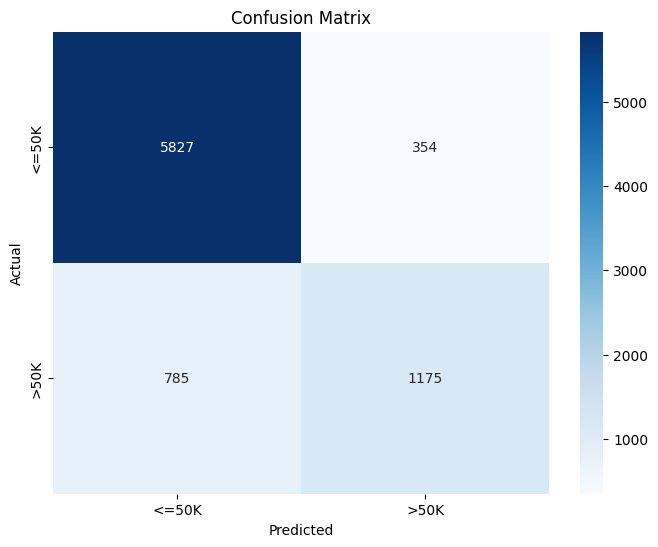

In [ ]:
# print the confusin matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



###* The Decision Tree achieved an accuracy of 86.0%.

###* Performance is strong for the lower income class (<=50k), with a precision of 88% and a recall of 94%.

###* However, for the higher income class (>50k), precision is moderate (77%) and recall is lower (60%), meaning that the model tends to miss a portion of higher earners.

###* This reflects the impact of class imbalance and suggest room for imporvement in capturing high-income cases.


# Modeling - Random Forest




In [ ]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# y = income_copy["income"].map({"<=50K": 0, ">50K": 1})  -> from cell above
# X = pd.get_dummies(income_copy, drop_first=True) -> from cell above

# We use 25% for test size, random state of 42 to ensure reproducible splits, and
# stratification of y to preserve original class distribution between training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
                                                    random_state= 42, stratify = y)
# Instantiate an instance of the RandomForestClassifier class
# For the baselien Random Forest, We set max_depth of 10, min sample split of 5

rf = RandomForestClassifier(
    n_estimators = 700, # A larger number of trees was used to stabilize predictions
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs = -1
)

rf.fit(X_train, y_train)

importance_rf = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).round(3)

print(importance_rf)

                                 feature  importance
6      marital-status_Married-civ-spouse       0.206
2                           capital-gain       0.189
1                          education-num       0.158
0                                    age       0.072
8           marital-status_Never-married       0.061
4                         hours-per-week       0.053
3                           capital-loss       0.045
13            occupation_Exec-managerial       0.035
25            relationship_Not-in-family       0.030
34                              sex_Male       0.026
19             occupation_Prof-specialty       0.025
27                relationship_Own-child       0.022
28                relationship_Unmarried       0.013
29                     relationship_Wife       0.011
17              occupation_Other-service       0.009
38           workclass-agg_Self-Employed       0.004
14            occupation_Farming-fishing       0.004
37                 workclass-agg_Private      

###* Feature importance analysis shows that the model still indicates the same top features as DT: `marital- status`, `capital-gains`, `education-num`, `age`, and `hours-per-week`.
###* RF table shows a more graduat drop-off and fewer extreame zeros.
###* It indicates that the RF model distributes importances more evenly due to aggregation across multiple trees.

In [ ]:
# Evaluation

# Print out the accuracy scores
result_rf_train = round(rf.score(X_train, y_train), 3)
result_rf_test = round(rf.score(X_test, y_test), 3)

print(f'The training and testing accuracy of RandomForestClassifier are: {result_rf_train}, {result_rf_test}')

# Use the trained dt model to predict income labels
y_pred = rf.predict(X_test)

# Show where model is correct and incorrect
print('\nConfusion Matrix: ')
print(confusion_matrix(y_test, y_pred))

# Show precision, recall, F1,
print('\nClassification Report: ')
print(classification_report(y_test, y_pred))

The training and testing accuracy of RandomForestClassifier are: 0.868, 0.862

Confusion Matrix: 
[[5914  267]
 [ 854 1106]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6181
           1       0.81      0.56      0.66      1960

    accuracy                           0.86      8141
   macro avg       0.84      0.76      0.79      8141
weighted avg       0.86      0.86      0.85      8141



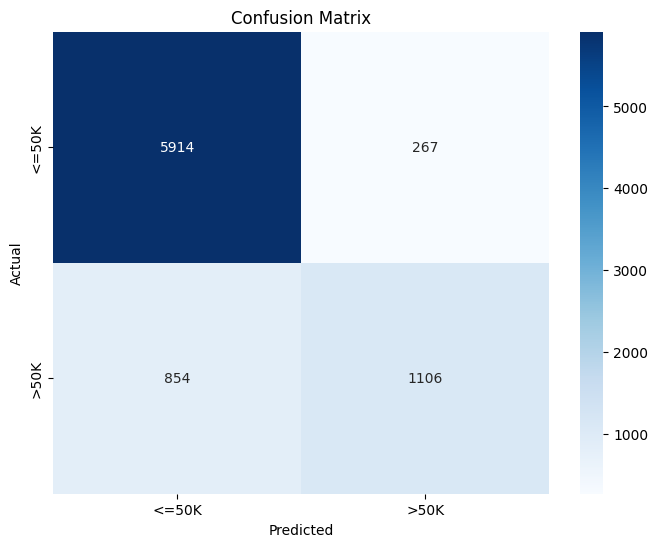

In [ ]:
# print the confusin matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Random Forest Analysis
* The Random Forest achieved a similar overall accuracy to the Decision Tree while improving precision for the high-income class (>50K).
* However, recall for high-income cases remains lower, indicating that the model is conservative in predicting higher income and continues to be influenced by class imbalance.
* The Confusion Matrix demonstrates that the model is strongest at predicting low-income people who earn <= 50k (True Negative), is conservative in predicting high-income people who truly earn > 50K, and is weakest at identifying high-income people who are misclassified as low-income (false negatives).
* This confusion matrix chart is consistent with the classification report where precision for the > 50K is 81% and recall > 50K is 56%.
* To increase the recall rate for high income cases, the model can benefit from Hyperparameter tuning.






## We will explore tuning the random forest classifier model by testing the performance over a range of max depth values from 1-25.

In [ ]:
# Tune the hyperparameter max_depth over a range from 1-25 and save scores for test and train set
import numpy as np
accuracy_train=[]
accuracy_test = []

for depth in range(1,25):
  rfc_25 = RandomForestClassifier(max_depth = depth, random_state=0)
  rfc_25.fit(X_train, y_train)
  accuracy_train.append(rfc_25.score(X_train, y_train))
  accuracy_test.append(rfc_25.score(X_test, y_test))

# Find the best accuracy and at what depth that occurs
best_accuracy = np.max(accuracy_test)
best_depth = np.argmax(accuracy_test)+1

print(f'The largest accuracy and depth of the test data are: {best_accuracy.round(4)} and {best_depth}')

The largest accuracy and depth of the test data are: 0.8655 and 17


The test accuracy increases form .86 to .8655, a marginally small improvement.

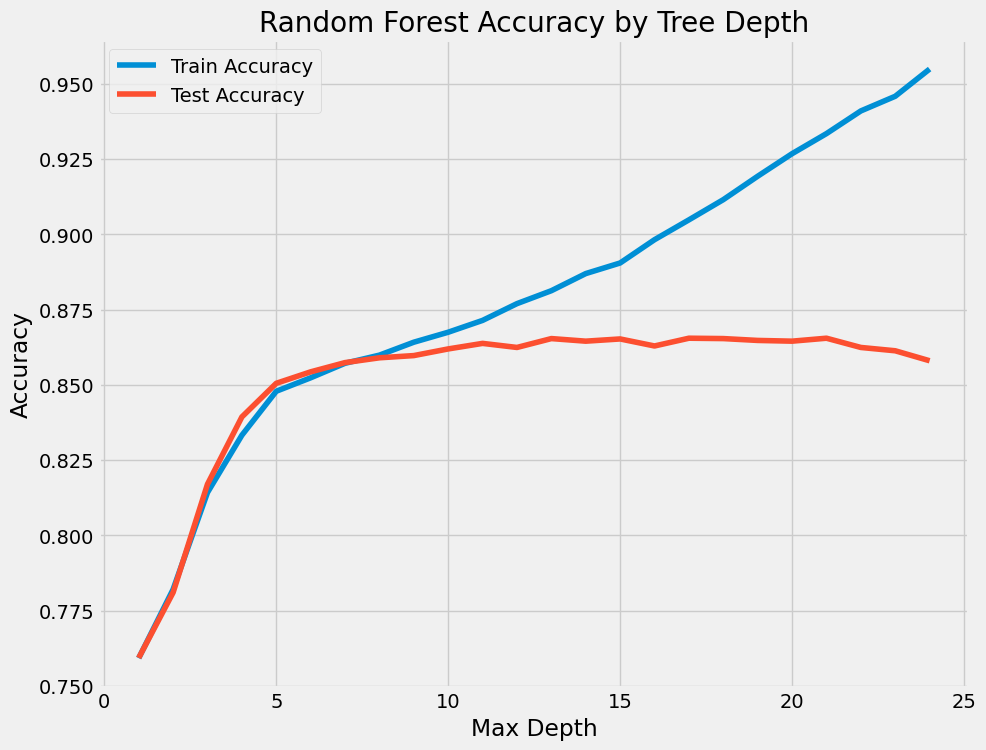

In [ ]:
# Plot the accuracy scores for the test and train set over the range of depth values
depths = range(1, 25)
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10,8))

plt.plot(depths, accuracy_train, label='Train Accuracy')
plt.plot(depths, accuracy_test, label='Test Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Max Depth')
plt.title('Random Forest Accuracy by Tree Depth')
plt.legend()

In [ ]:
# View the feature importance in a dataframe using the max depth parameter
best_rf = RandomForestClassifier(max_depth = best_depth, random_state=0)
best_rf.fit(X_train, y_train)
best_rf.score(X_test, y_test) # same as the loop result

print(round(best_rf.score(X_train, y_train), 4))
print(round(best_rf.score(X_test, y_test), 4))

importance_best_rf = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).round(3)

print((importance_best_rf)[:5])




0.9048
0.8655
                             feature  importance
2                       capital-gain       0.165
1                      education-num       0.157
6  marital-status_Married-civ-spouse       0.146
0                                age       0.118
4                     hours-per-week       0.079


## The accuracy test score matches the result from the loop which is 86.55%. But training result of 90.48% indicates that there is slight overfitting.

## The model can adapt the Randomize Search Cross Validation tool to find the optimal parameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid ={
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 5, 15, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 20]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter = 10,
    cv = 5,
    scoring = 'f1',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': None}
Best Score: 0.6730573334448159


In [ ]:
# Model tuning report
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print(best_rf)

# Accuracy (comparing overall modelperformance)
print(f'Traing accuracy: {round(best_rf.score(X_train, y_train), 3)}')
print(f'Test accuracy: {round(best_rf.score(X_test, y_test), 3)}')

importance_rf = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).round(3)

print(importance_rf)

print('\nConfusion Matrix: ')
print(confusion_matrix(y_test, y_pred))

# F1 score for the high-income class (>50k) is used to evaluate the balance
# between precision and recall due to class imbalance

print('\nClassification Report: ')
print(classification_report(y_test, y_pred))


RandomForestClassifier(min_samples_leaf=5, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)
0.878
0.866
                                 feature  importance
6      marital-status_Married-civ-spouse       0.188
2                           capital-gain       0.172
1                          education-num       0.161
0                                    age       0.097
4                         hours-per-week       0.063
8           marital-status_Never-married       0.054
3                           capital-loss       0.040
13            occupation_Exec-managerial       0.034
19             occupation_Prof-specialty       0.028
25            relationship_Not-in-family       0.026
34                              sex_Male       0.023
27                relationship_Own-child       0.018
28                relationship_Unmarried       0.012
29                     relationship_Wife       0.012
17              occupation_Other-service       0.011
37     

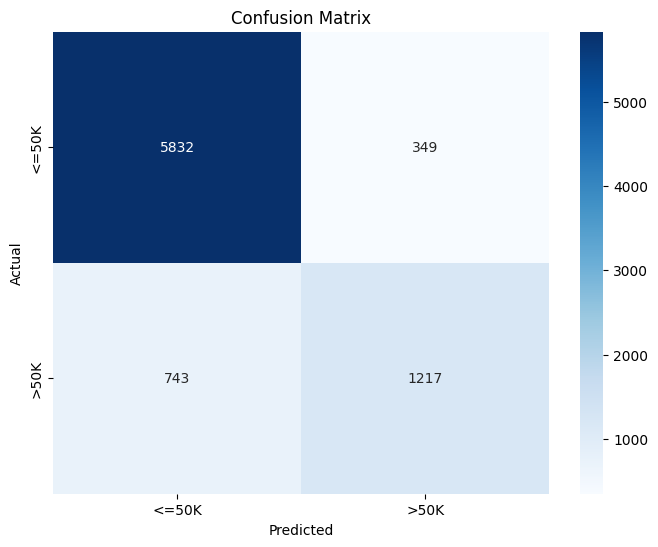

In [ ]:
# print the confusin matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# RandomizedSearchCV Analysis

###* RandomizedSearchCV is used to tune Random Forest hyperparameters using 5-fold cross-validation with F1-score as the optimization metric to address class imbalance.
###* The tuned model achieves a higher F1-score for the high-income (>50K) class while maintaining similar overall accuracy compared to the baseline Random Forest.
###* Cross-validation results are consistent with test-set performance, indicating stable generalization and no evidence of overfitting.
###* The model correctly classifies most low-income individuals (≤50K), with 5,914 true negatives and a low false-positive rate (267 cases misclassified as >50K).
###* Performance on the high-income class (>50K) is weaker, with 1,106 true positives but a relatively high number of false negatives (854).
###* This indicates the model is conservative when predicting high-income cases, prioritizing precision over recall for the >50K class.
###* The imbalance between false negatives and false positives confirms that class imbalance continues to affect recall for the >50K group.
## Overall, the Random Forest improves stability over a single Decision Tree but does not fully resolve minority-class recall.